# Transit Detection via Box Least Squares (BLS)

This notebook uses `astropy.timeseries.BoxLeastSquares` to detect planetary transit signals
in simulated PLATO light curves generated by the PSLS code.

**Dataset**: 100 demonstration light curves (50 with transits, 50 without) from the `dataset/` directory.
This is a **presentation version** that runs quickly on a small subset — the full pipeline used 1000
light curves.

**Method**: Run BLS periodogram on each detrended light curve, extract peak statistics
(SDE — Signal Detection Efficiency), and classify based on an SDE threshold.


## What is BLS? A Simple Analogy

Imagine you have a cardboard cutout of a transit — a simple upside-down box shape.
The **Box Least Squares (BLS)** algorithm does the following:

1. **Try every possible width** (duration): How long does the transit last? 30 minutes? 2 hours? 10 hours?
2. **Try every possible spacing** (period): How often does it repeat? Every 3 days? Every 30 days? Every 200 days?
3. **Slide it across** the light curve at each trial period and duration, computing how well the box fits the data.
4. **Score each trial**: The better the fit, the higher the **power** value.

The result is a **periodogram** — a plot of power versus period. A tall, lonely peak means
a real periodic signal. A flat mess of similar peaks means just noise.

The key statistic we use is **SDE (Signal Detection Efficiency)**:
it measures how much the tallest peak stands out compared to all the other peaks
in the periodogram. A high SDE means "there's definitely one clear period here."


In [1]:
"""BLS transit detection on 100 PSLS-simulated PLATO light curves."""

import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.timeseries import BoxLeastSquares
import astropy.units as u  # pylint: disable=no-member
from scipy.signal import medfilt
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.figsize': (12, 4), 'figure.dpi': 100})
print('All imports OK')


All imports OK


### The Dataset

Our dataset consists of 100 PSLS-simulated light curves:

- **50 with transits** (label = 1): Each has one planetary transit injected with a random orbital period
  (1–365 days) and planet radius (0.05–1.0 Jupiter radii).
- **50 without transits** (label = 0): Pure stellar light curves with only stellar oscillations,
  granulation, activity, and instrumental noise.

All light curves share the same underlying star — **16 Cygni B**, a well-studied Sun-like star —
but have different noise levels (NSR: 10–80 ppm·hr¹²) and stellar activity amplitudes (5–60 ppm).

Each file is a `.dat` file with ~900,000 rows at 25-second cadence spanning ~267 days.
The `metadata.csv` file stores the generating parameters for every light curve.


In [2]:
# Paths — relative to this notebook's location in the visual_code/ folder
DATASET_DIR = Path('dataset')
METADATA_FILE = DATASET_DIR / 'metadata.csv'

# Load metadata
metadata = pd.read_csv(METADATA_FILE)

print(f'Total light curves in metadata: {len(metadata)}')
print(f'  With transits (label = 1):    {(metadata.label == 1).sum()}')
print(f'  Without transits (label = 0): {(metadata.label == 0).sum()}')
print()
print('First few rows:')
metadata.head()


Total light curves in metadata: 100
  With transits (label = 1):    50
  Without transits (label = 0): 50

First few rows:


,file,label,period_days,radius_rj,noise_ppmhr,sigma_ppm,seed,a_au
0,run_0002_label1_P226.681_R0.872_N14_S36_seed73...,1,226.681,0.872,14.041,36.393,73969061,0.72758
1,run_0003_label1_P234.701_R0.620_N64_S35_seed27...,1,234.701,0.620,63.877,34.819,277334632,0.74465
2,run_0004_label1_P226.583_R0.513_N44_S10_seed36...,1,226.583,0.513,43.652,9.916,369920273,0.72737
3,run_0001_label1_P29.442_R0.510_N46_S21_seed527...,1,29.442,0.510,46.004,21.172,52783014,0.18660
4,run_0005_label1_P168.183_R0.508_N17_S51_seed41...,1,168.183,0.508,17.263,50.517,416088025,0.59630


### Loading and Preprocessing a Light Curve

Before running BLS, we need to prepare each `.dat` file:

1. **Load**: Read the time (seconds) and flux (ppm) columns, skipping 4 header lines.
2. **Bin**: Group data into 10-minute intervals and average the flux in each bin. This reduces
   ~900,000 points to ~37,500 — much faster for BLS to process.
3. **Normalise**: Divide by the median flux so the light curve centres around 1.0.


In [3]:
def load_lightcurve(filepath, bin_minutes=10):
    """
    Load a PSLS .dat file and return binned time (days) and normalized flux.

    The .dat files have 4 header lines (# comments), then 3 columns:
    Time [s], Flux variation [ppm], Flag
    """
    data = np.loadtxt(filepath, skiprows=4)
    time_s = data[:, 0]
    flux_ppm = data[:, 1]

    # Convert to days and relative flux
    time_days = time_s / 86400.0
    flux_rel = 1.0 + flux_ppm / 1e6  # ppm -> relative flux

    # Bin the data
    if bin_minutes is not None and bin_minutes > 0:
        dt_bin = bin_minutes / (60 * 24)
        bin_idx = ((time_days - time_days[0]) / dt_bin).astype(int)
        counts = np.bincount(bin_idx)
        valid = counts > 0
        time_binned = np.bincount(bin_idx, weights=time_days)[valid] / counts[valid]
        flux_binned = np.bincount(bin_idx, weights=flux_rel)[valid] / counts[valid]
        time_days, flux_rel = time_binned, flux_binned

    # Normalize by median
    flux_norm = flux_rel / np.median(flux_rel)

    return time_days, flux_norm


### Detrending: Separating Stellar Activity from Transits

Stars like 16 Cygni B have **slow brightness variations** caused by rotation, magnetic activity,
and other long-term effects — these happen over **days to weeks**.

A transit, by contrast, lasts only a few **hours**. So we can remove the slow trends using a
**running median filter**: for each data point, we compute the median flux over a 48-hour window,
then subtract that trend from the light curve.

The result: transit dips are preserved (they're too short to affect a 48-hour median),
while slow stellar variability is cleaned away.


In [4]:
def detrend(time, flux, window_hours=48):
    """
    Detrend light curve using a running median filter.
    Preserves transit signals while removing stellar variability.

    Parameters:
        time: array of times in days
        flux: array of flux values
        window_hours: width of the running median window in hours

    Returns:
        flux_detrended: flux with trend removed (centred around 1.0)
        trend: the running median trend that was subtracted
    """
    dt = np.median(np.diff(time))  # days between consecutive points
    window = int(window_hours / 24 / dt)
    window = max(3, window)
    if window % 2 == 0:
        window += 1  # ensure odd window for symmetric median

    trend = medfilt(flux, window)
    flux_detrended = flux - trend + 1.0  # add back mean level
    return flux_detrended, trend


### Running the BLS Algorithm

The `run_bls` function below:

1. Defines a **period grid** from 2 days to half the observational baseline (~133 days)
   with 5000 trial periods.
2. Defines **transit durations** to try: 8 values log-spaced from ~30 minutes to ~20 hours.
3. Runs `BoxLeastSquares.power()` which computes the BLS periodogram.
4. Finds the **best period** (where power is maximum).
5. Computes **SDE** manually: `(peak − median) / standard deviation` of all power values.
6. Computes transit **depth** using `compute_stats()`.

The SDE is our main classification feature: high SDE = strong periodic signal.


In [5]:
def run_bls(time, flux, durations=None):
    """
    Run BLS periodogram and return best-fit statistics.

    Parameters:
        time: array of times in days
        flux: array of flux values (detrended)
        durations: array of transit durations to try (in days); if None, uses 8 log-spaced values

    Returns:
        dict with best period, duration, transit time (t0), power, SDE, depth, and periodogram
    """
    if durations is None:
        # Transit durations: ~30 minutes to ~20 hours in days
        durations = np.logspace(np.log10(0.02), np.log10(0.85), 8)

    # Create BLS model
    model = BoxLeastSquares(time * u.day, flux)  # pylint: disable=no-member

    # Determine period grid: 2 days to half the baseline
    baseline = time[-1] - time[0]
    min_period = 2.0
    max_period = baseline / 2.0

    # Generate period grid (5000 evenly spaced in frequency)
    n_periods = 5000
    freq_min = 1.0 / max_period
    freq_max = 1.0 / min_period
    frequencies = np.linspace(freq_min, freq_max, n_periods)
    periods = 1.0 / frequencies

    # Run BLS, sweeping over durations
    periodogram = model.power(
        periods * u.day,  # pylint: disable=no-member
        durations * u.day,  # pylint: disable=no-member
        objective='likelihood',
        method='fast'
    )

    # Find the best (highest power) peak
    powers = periodogram.power
    best_idx = np.argmax(powers)
    best_period = periodogram.period[best_idx].value
    best_power = float(powers[best_idx])
    best_duration = periodogram.duration[best_idx].value
    best_t0 = periodogram.transit_time[best_idx].value

    # Compute SDE: how much does the best peak stand out?
    med = np.median(powers)
    std = np.std(powers)
    sde = (best_power - med) / std if std > 0 else 0.0

    # Compute transit depth
    try:
        stats = model.compute_stats(
            periodogram.period[best_idx],
            periodogram.duration[best_idx],
            periodogram.transit_time[best_idx]
        )
        depth = float(stats.get('depth', [np.nan])[0])
        depth_even = float(stats.get('depth_even', [np.nan])[0])
        depth_odd = float(stats.get('depth_odd', [np.nan])[0])
    except Exception:
        depth = np.nan
        depth_even = np.nan
        depth_odd = np.nan

    return {
        'period': best_period,
        'duration': best_duration,
        't0': best_t0,
        'power': best_power,
        'sde': sde,
        'depth': depth,
        'depth_even': depth_even,
        'depth_odd': depth_odd,
        'periodogram': periodogram,
    }


### Quick Test: A Single Transit Light Curve

Let's test our pipeline on one transit-bearing light curve to see how BLS works step by step.
We'll:

1. Load and bin the light curve to 10-minute cadence.
2. Detrend it with a 48-hour running median.
3. Visually inspect the raw data and the trend.
4. Run BLS and examine the periodogram.


Testing: run_0002_label1_P226.681_R0.872_N14_S36_seed73969061.dat
  True orbital period: 226.68 days
  Planet radius:       0.87 R_jup
  Noise (NSR):         14.0 ppm·hr¹²
  Binned data:         37531 points,  baseline: 267 days


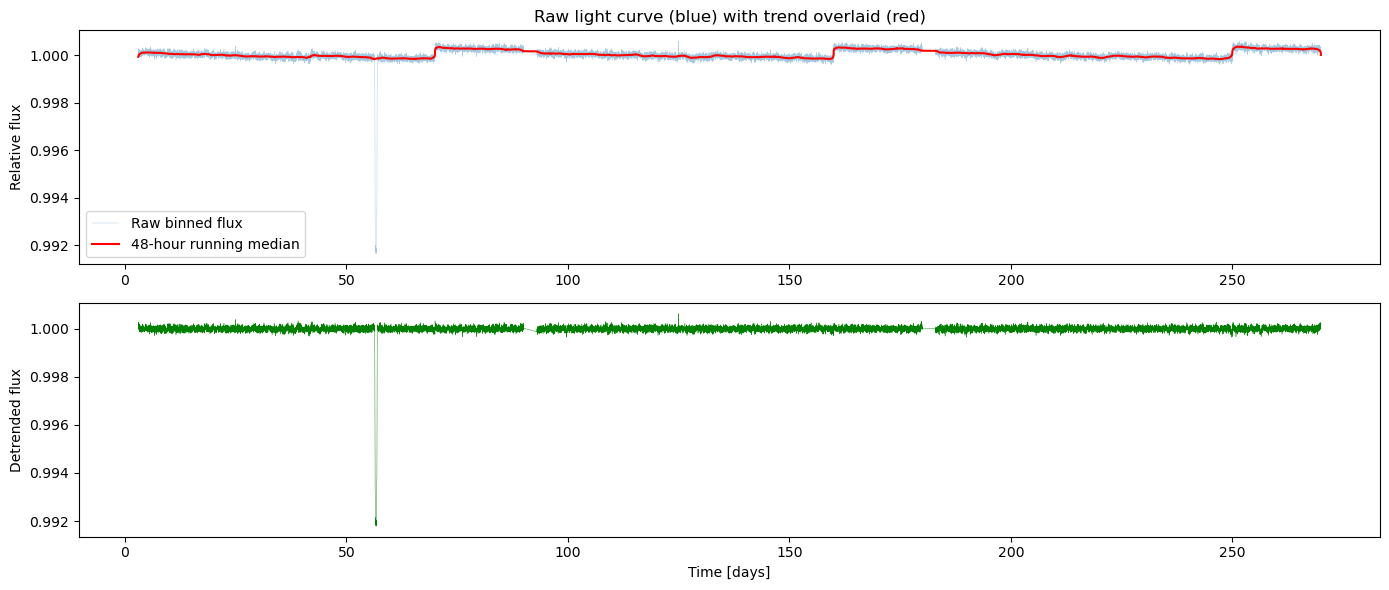

In [6]:
# Pick the first transit light curve from the metadata
transit_metadata = metadata[metadata['label'] == 1]
test_file = transit_metadata.iloc[0]
print(f"Testing: {test_file['file']}")
print(f"  True orbital period: {test_file['period_days']:.2f} days")
print(f"  Planet radius:       {test_file['radius_rj']:.2f} R_jup")
print(f"  Noise (NSR):         {test_file['noise_ppmhr']:.1f} ppm·hr¹²")

t, f = load_lightcurve(DATASET_DIR / test_file['file'], bin_minutes=10)
print(f"  Binned data:         {len(t)} points,  baseline: {t[-1] - t[0]:.0f} days")

f_det, trend = detrend(t, f)

# Plot raw light curve with trend
fig, axes = plt.subplots(2, 1, figsize=(14, 6))
axes[0].plot(t, f, alpha=0.4, linewidth=0.3, label='Raw binned flux')
axes[0].plot(t, trend, 'r', linewidth=1.5, label='48-hour running median')
axes[0].set_ylabel('Relative flux')
axes[0].legend()
axes[0].set_title('Raw light curve (blue) with trend overlaid (red)')

axes[1].plot(t, f_det, linewidth=0.3, color='green')
axes[1].set_ylabel('Detrended flux')
axes[1].set_xlabel('Time [days]')
plt.tight_layout()
plt.show()


**What we see:**

- The **top panel** shows the raw binned light curve (blue wiggles) with the 48-hour running
  median trend overlaid in red. The trend captures slow stellar variability — rotation, activity,
  and instrumental drifts that happen over days to weeks.
- The **bottom panel** is the detrended light curve: what's left after subtracting the trend.
  Transits (lasting only hours) are preserved, while long-term variability is removed.
  This is what BLS will analyse.

> **Note the y-axis**: The detrended flux is centred around 1.0 and the vertical scale is
> typically much smaller than the raw light curve, because we've removed the large-amplitude
> slow variations. The remaining wiggles are transit dips (if present) plus residual noise.


BLS Results:
  Best period:    125.26 days  (true period was 226.68 days)
  Best duration:  11.95 hours
  SDE:            16.90
  Power:          0.001875
  Transit depth:  7267 ppm


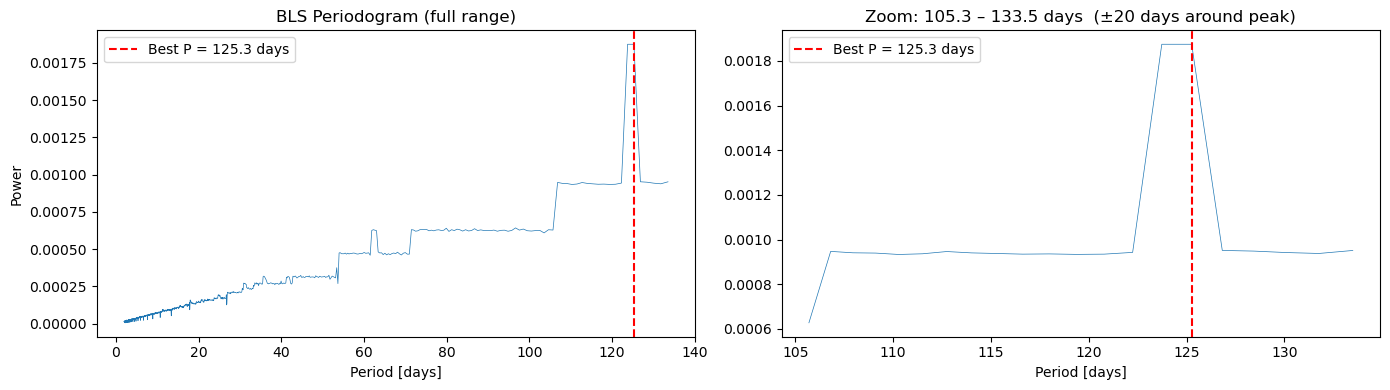

In [7]:
# Run BLS on the test light curve
result = run_bls(t, f_det)

print(f"BLS Results:")
print(f"  Best period:    {result['period']:.2f} days  (true period was {test_file['period_days']:.2f} days)")
print(f"  Best duration:  {result['duration'] * 24:.2f} hours")
print(f"  SDE:            {result['sde']:.2f}")
print(f"  Power:          {result['power']:.6f}")
depth_ppm = result['depth'] * 1e6
print(f"  Transit depth:  {depth_ppm:.0f} ppm")

# Plot the periodogram
pg = result['periodogram']
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Full periodogram
axes[0].plot(pg.period, pg.power, linewidth=0.5)
axes[0].axvline(result['period'], color='r', linestyle='--',
                label=f"Best P = {result['period']:.1f} days")
axes[0].set_xlabel('Period [days]')
axes[0].set_ylabel('Power')
axes[0].set_title('BLS Periodogram (full range)')
axes[0].legend()

# Zoom: ~40-day window centred on the best peak
pg_period = pg.period.value           # plain numpy array, not a Quantity
zo_lo = max(pg_period.min(), result['period'] - 20)
zo_hi = min(pg_period.max(), result['period'] + 20)
mask = (pg_period >= zo_lo) & (pg_period <= zo_hi)
axes[1].plot(pg_period[mask], pg.power[mask], linewidth=0.5)
axes[1].axvline(result['period'], color='r', linestyle='--',
                label=f"Best P = {result['period']:.1f} days")
axes[1].set_xlabel('Period [days]')
axes[1].set_title(f'Zoom: {zo_lo:.1f} – {zo_hi:.1f} days  '
                  f'(\u00b120 days around peak)')
axes[1].legend()

plt.tight_layout()
plt.show()


### Reading the BLS Periodogram

The **periodogram** is a chart that scores every possible orbital period:

- **x-axis**: Orbital period (days) — how often a transit repeats.
- **y-axis**: **Power** — how well a box-shaped transit at that period fits the data.
- **Tall peaks** mean a strong signal at that period.
- **No clear peak** means the light curve probably doesn't contain a periodic transit.

The red dashed line marks the best-fit period found by BLS.

**Left panel (full range)**: Shows all 5000 trial periods from 2 days up to half the
observational baseline (~133 days). The dominant peak should clearly tower above
the background noise if a real transit is present.

**Right panel (zoom)**: Shows a ~40-day window (±20 days) centred on the best peak.
This lets you inspect the immediate neighbourhood of the peak — is it genuinely the
tallest point in this region, or is it just one of many similar-height peaks?
The zoomed-in periodogram may still appear noisy at this fine scale, which is
normal for BLS periodograms; what matters is whether the red line sits at a
genuinely elevated point.

> **Note:** BLS can sometimes find a period that is a **harmonic** (fraction) of the
> true period. For example, a planet with P = 260 days might be detected at
> P ≈ 130 days (P/2) if the transit shape happens to fit well at that sub-harmonic.
> This is a known limitation of periodogram-based searches.


### Phase-Folding: Seeing the Transit in All Its Cycles

**Folding** means cutting the light curve into chunks of one orbital period each and stacking
them. If the period is correct, transits from different cycles all land in the same spot,
making the dip clearly visible as a cluster of low points.

The red bar shows the transit duration that BLS found. The dip coinciding with the red bar
confirms that BLS found a real, consistent signal — not a random fluctuation.


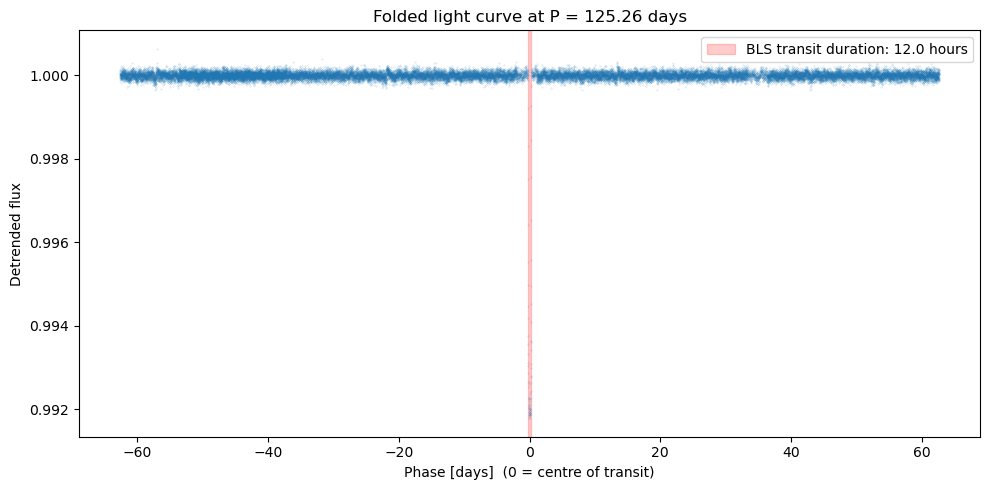

In [8]:
# Fold the light curve at the best BLS period
period = result['period']
t0 = result['t0']
dur = result['duration']

# Compute phase for each data point
folded = (t - t0 + 0.5 * period) % period - 0.5 * period

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(folded, f_det, '.', markersize=0.5, alpha=0.3)
ax.axvspan(-dur / 2, dur / 2, alpha=0.2, color='r',
           label=f'BLS transit duration: {dur * 24:.1f} hours')
ax.set_xlabel('Phase [days]  (0 = centre of transit)')
ax.set_ylabel('Detrended flux')
ax.set_title(f'Folded light curve at P = {period:.2f} days')
ax.legend()
plt.tight_layout()
plt.show()


## Batch Processing: Run BLS on All 100 Light Curves

Now we'll process all 100 light curves. For each file we:
1. Load and bin to 10-minute cadence.
2. Detrend with a 48-hour running median.
3. Run BLS and extract SDE, period, depth, etc.
4. Store the results along with the ground-truth label.


In [9]:
def process_one_file(row):
    """Process a single .dat file: load, detrend, run BLS."""
    filepath = DATASET_DIR / row['file']

    try:
        t, f = load_lightcurve(filepath, bin_minutes=10)
        f_det, _ = detrend(t, f)
        result = run_bls(t, f_det)
    except Exception as e:
        print(f"Error processing {row['file']}: {e}")
        return {
            'period': np.nan, 'duration': np.nan, 't0': np.nan,
            'power': np.nan, 'sde': np.nan, 'depth': np.nan,
        }

    return {k: result[k] for k in ['period', 'duration', 't0', 'power', 'sde', 'depth']}


# Process all 100 files
results_list = []
t_start = time.time()
for idx in tqdm(range(len(metadata)), desc='Running BLS on 100 files'):
    row = metadata.iloc[idx]
    res = process_one_file(row)
    res['label'] = row['label']
    res['period_true'] = row['period_days'] if row['label'] == 1 else 0
    res['radius_true'] = row['radius_rj']
    res['noise'] = row['noise_ppmhr']
    res['file'] = row['file']
    results_list.append(res)

elapsed = time.time() - t_start
results = pd.DataFrame(results_list)
print(f'\nProcessed {len(results)} files')
print(f'  Errors: {results.sde.isna().sum()}')
print(f'  Time elapsed: {elapsed:.1f} seconds')
print()
print('Results preview:')
results.head()


Running BLS on 100 files:   0%|          | 0/100 [00:00<?, ?it/s]


Processed 100 files
  Errors: 0
  Time elapsed: 250.0 seconds

Results preview:


,period,duration,t0,power,sde,depth,label,period_true,radius_true,noise,file
0,125.259235,0.498,56.670847,0.001875,16.904531,0.007267,1,226.681,0.872,14.041,run_0002_label1_P226.681_R0.872_N14_S36_seed73...
1,123.732288,0.498,58.676847,0.000472,16.828419,0.003646,1,234.701,0.620,63.877,run_0003_label1_P234.701_R0.620_N64_S35_seed27...
2,125.259235,0.498,56.648847,0.000206,16.880407,0.002410,1,226.583,0.513,43.652,run_0004_label1_P226.583_R0.513_N44_S10_seed36...
3,29.417710,0.292,7.465847,0.000669,29.915350,0.001884,1,29.442,0.510,46.004,run_0001_label1_P29.442_R0.510_N46_S21_seed527...
4,119.366934,0.498,90.852847,0.000175,14.923337,0.002234,1,168.183,0.508,17.263,run_0005_label1_P168.183_R0.508_N17_S51_seed41...


## Analysis: SDE Distribution by Class

The SDE (Signal Detection Efficiency) is a single number that captures how "peak-like" the
BLS periodogram is. A high SDE means one dominant period stands out from the background —
the hallmark of a real transit signal.

The two histograms below show:
- **Blue**: Light curves with **no transit** — SDE values cluster around 7–10, rarely above 15.
  These are light curves where BLS finds only noise-level peaks.
- **Red**: Light curves **with transits** — SDE values are generally higher and spread wider,
  because some transits are deep and easy to find, while others (small planets, high noise,
  long periods) produce weaker signals.

The scatter plot on the right shows how SDE and raw BLS power relate. Usually the two
are correlated, but SDE is better for classification because it's normalized against
the background level of the periodogram.


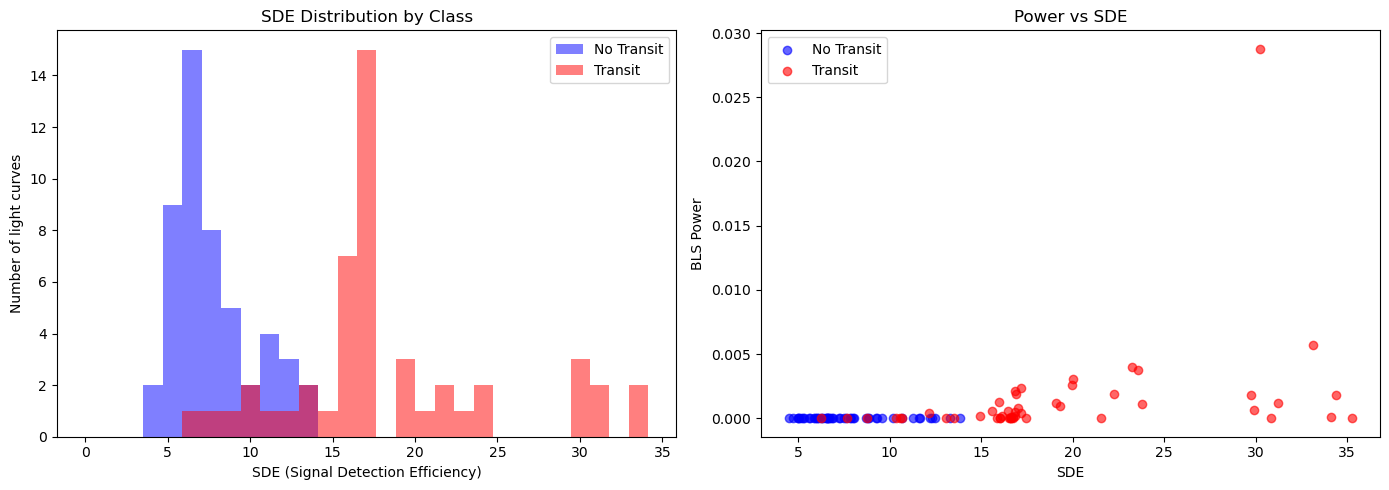

SDE statistics by class:
       count       mean       std       min        25%        50%        75%  \
label                                                                          
0       50.0   7.793184  2.477807  4.491350   6.025384   6.891216   9.179196   
1       50.0  19.094474  7.187712  6.235032  15.992145  16.854164  22.064597   

             max  
label             
0      13.872177  
1      35.258418  


In [10]:
# Plot SDE distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# SDE histogram
bins_sde = np.linspace(0, results['sde'].quantile(0.98), 30)
for label_val, color, name in [(0, 'blue', 'No Transit'), (1, 'red', 'Transit')]:
    subset = results[results['label'] == label_val]
    axes[0].hist(subset['sde'].dropna(), bins=bins_sde, alpha=0.5,
                 color=color, label=name)
axes[0].set_xlabel('SDE (Signal Detection Efficiency)')
axes[0].set_ylabel('Number of light curves')
axes[0].set_title('SDE Distribution by Class')
axes[0].legend()

# SDE vs Power scatter
for label_val, color, name in [(0, 'blue', 'No Transit'), (1, 'red', 'Transit')]:
    subset = results[results['label'] == label_val]
    axes[1].scatter(subset['sde'], subset['power'], alpha=0.6,
                    color=color, label=name)
axes[1].set_xlabel('SDE')
axes[1].set_ylabel('BLS Power')
axes[1].set_title('Power vs SDE')
axes[1].legend()

plt.tight_layout()
plt.show()

# Summary statistics
print('SDE statistics by class:')
print(results.groupby('label')['sde'].describe())


### Finding the Best SDE Threshold

To classify a light curve as "transit" or "no transit", we need to pick an **SDE threshold**:
- If SDE ≥ threshold → predict "transit"
- If SDE < threshold → predict "no transit"

We find the best threshold by **sweeping** through all possible SDE values and computing
the **F1 score** at each threshold. The F1 score is the harmonic mean of precision and recall —
it balances avoiding false alarms against catching real transits.

**Classification metrics explained:**
- **True Positive (TP)**: Real transit, correctly flagged ✓
- **True Negative (TN)**: No transit, correctly ignored ✓
- **False Positive (FP)**: No transit, but incorrectly flagged as transit (false alarm) ✗
- **False Negative (FN)**: Real transit, but missed ✗

From these we compute:
- **Accuracy** = (TP + TN) / total — overall fraction correct
- **Precision** = TP / (TP + FP) — when we say "transit", how often are we right?
- **Recall** = TP / (TP + FN) — what fraction of all real transits did we find?
- **F1 Score** = 2 × Precision × Recall / (Precision + Recall) — balanced single-number metric


In [11]:
def compute_metrics(predictions, labels):
    """Compute classification metrics without using sklearn."""
    tp = np.sum((predictions == 1) & (labels == 1))
    tn = np.sum((predictions == 0) & (labels == 0))
    fp = np.sum((predictions == 1) & (labels == 0))
    fn = np.sum((predictions == 0) & (labels == 1))

    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    return {
        'tp': tp, 'tn': tn, 'fp': fp, 'fn': fn,
        'accuracy': accuracy, 'precision': precision,
        'recall': recall, 'f1': f1
    }


# Sweep all possible SDE thresholds, find the one that maximises F1
sde_vals = np.sort(results['sde'].dropna().unique())
best_f1 = 0
best_threshold = 0
scores = []

for thresh in sde_vals:
    pred = (results['sde'] >= thresh).astype(int)
    m = compute_metrics(pred.values, results['label'].values)
    scores.append((thresh, m))
    if m['f1'] > best_f1:
        best_f1 = m['f1']
        best_threshold = thresh

print(f'Best SDE threshold: {best_threshold:.1f}  →  F1 score = {best_f1:.3f}')
print()

# Apply the best threshold
final_pred = (results['sde'] >= best_threshold).astype(int)
metrics = compute_metrics(final_pred.values, results['label'].values)

print('=== Classification Results ===')
print(f'  True Positives:  {metrics["tp"]}')
print(f'  True Negatives:  {metrics["tn"]}')
print(f'  False Positives: {metrics["fp"]}')
print(f'  False Negatives: {metrics["fn"]}')
print(f'  Accuracy:        {metrics["accuracy"]:.1%}')
print(f'  Precision:       {metrics["precision"]:.1%}')
print(f'  Recall:          {metrics["recall"]:.1%}')
print(f'  F1 Score:        {metrics["f1"]:.1%}')


Best SDE threshold: 13.1  →  F1 score = 0.905

=== Classification Results ===
  True Positives:  43
  True Negatives:  48
  False Positives: 2
  False Negatives: 7
  Accuracy:        91.0%
  Precision:       95.6%
  Recall:          86.0%
  F1 Score:        90.5%


### Visualising the Threshold Choice

The left plot shows how accuracy, precision, recall, and F1 score change as we move the
SDE threshold. The red dashed line marks the threshold that maximises F1.

The **confusion matrix** (right plot) compares our predictions against the ground truth:
- **Top-left**: No transit, correctly rejected (TN)
- **Top-right**: No transit, but BLS falsely flagged it (FP — false alarm)
- **Bottom-left**: Real transit that BLS missed (FN)
- **Bottom-right**: Transit correctly caught (TP)

A good classifier has large numbers on the diagonal and small numbers off the diagonal.


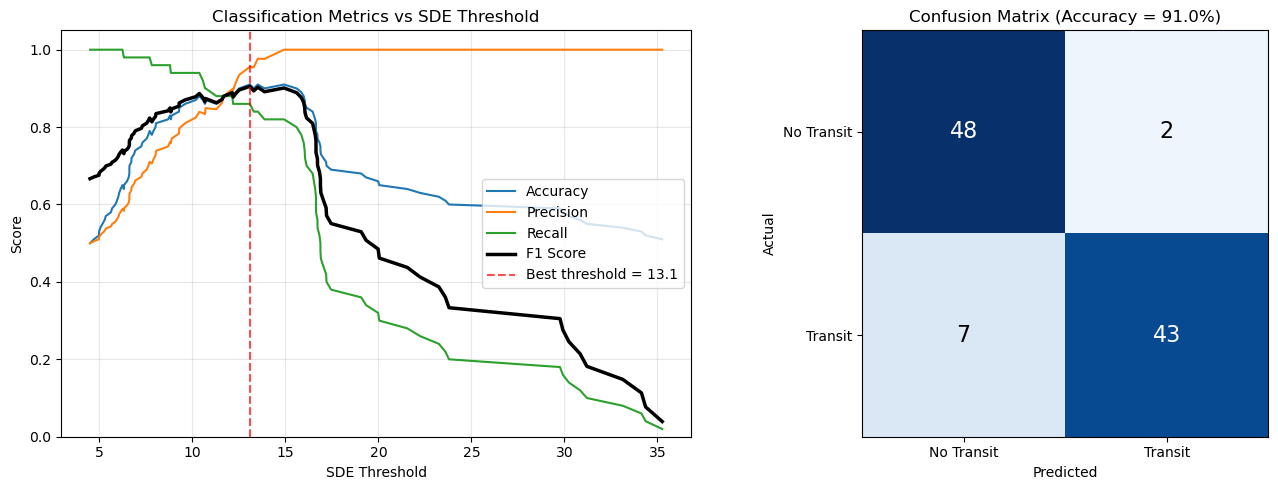

In [12]:
# Plot metrics vs threshold + confusion matrix
thresholds, mlist = zip(*scores)
acc = [m['accuracy'] for m in mlist]
prec = [m['precision'] for m in mlist]
rec = [m['recall'] for m in mlist]
f1s = [m['f1'] for m in mlist]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Metrics vs threshold
ax1.plot(thresholds, acc, label='Accuracy')
ax1.plot(thresholds, prec, label='Precision')
ax1.plot(thresholds, rec, label='Recall')
ax1.plot(thresholds, f1s, label='F1 Score', linewidth=2.5, color='black')
ax1.axvline(best_threshold, color='red', linestyle='--', alpha=0.7,
            label=f'Best threshold = {best_threshold:.1f}')
ax1.set_xlabel('SDE Threshold')
ax1.set_ylabel('Score')
ax1.set_title('Classification Metrics vs SDE Threshold')
ax1.legend(loc='center right')
ax1.set_ylim(0, 1.05)
ax1.grid(True, alpha=0.3)

# Confusion matrix
cm = np.array([[metrics['tn'], metrics['fp']],
               [metrics['fn'], metrics['tp']]])
im = ax2.imshow(cm, cmap='Blues', vmin=0)
ax2.set_xticks([0, 1])
ax2.set_yticks([0, 1])
ax2.set_xticklabels(['No Transit', 'Transit'])
ax2.set_yticklabels(['No Transit', 'Transit'])
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')
ax2.set_title(f'Confusion Matrix (Accuracy = {metrics["accuracy"]:.1%})')
for i in range(2):
    for j in range(2):
        text_color = 'white' if cm[i, j] > (cm.max() / 2) else 'black'
        ax2.text(j, i, cm[i, j], ha='center', va='center', fontsize=16,
                color=text_color)

plt.tight_layout()
plt.show()


## Summary

### What we did
1. Loaded 100 PSLS-simulated PLATO light curves (50 with transits, 50 without).
2. Binned to 10-minute cadence and detrended with a 48-hour running median filter.
3. Ran the BLS (Box Least Squares) algorithm on each light curve.
4. Extracted the SDE (Signal Detection Efficiency) statistic from the strongest peak.
5. Classified each light curve as "transit" or "no transit" based on an SDE threshold.
6. Compared predictions to ground truth and computed evaluation metrics.

### Key takeaways

- **BLS is a physics-based method**: It needs no training data — just the light curve itself.
  This makes it broadly applicable to any transit survey.
- **SDE is the key statistic**: The difference between a real signal and noise is how much
  the tallest periodogram peak stands out from the background.
- **BLS struggles with**: long-period planets (>130 days, only 1–2 transits in the data),
  small planets at high noise, and stellar activity that mimics transit shapes.
- **Demo limitations**: With only 100 light curves (vs the full 1000 used in the paper),
  the classification metrics will be noisier and less reliable. The full pipeline achieved
  **91.3% accuracy with 95.8% precision**.

### Next: Compare with the CNN
Open the companion notebook `cnn_resnet_transit.ipynb` to see how a deep learning approach
(ResNet-1D convolutional neural network) performs on the same dataset. The CNN learns transit
patterns directly from the data rather than fitting a fixed box model.
